In [ ]:
import os
import requests

start = '2022-03-19T00:00:00+00:00'
end =   '2022-03-29T00:00:00+00:00'

response = requests.get(
  'https://api.stormglass.io/v2/weather/point',
  params={
    'lat': 45.41497, # coordonnées de Méribel
    'lng': 6.5650,
    'params': ','.join(['airTemperature', 'snowDepth', 'precipitation', 'cloudCover']),
    'start': start,
    'end': end
  },
  headers={
    'Authorization': os.environ.get('STORMGLASS_API_KEY', '')
  }
)

In [ ]:
json_data = response.json()
print(json_data['meta']['requestCount'])

5


In [ ]:
print(len(json_data['hours']))

241


In [ ]:
from pandas import json_normalize
df_snow = json_normalize(json_data['hours'])

df_snow.head

<bound method NDFrame.head of                           time  airTemperature.noaa  airTemperature.sg  \
0    2022-03-19T00:00:00+00:00                -2.36              -2.36   
1    2022-03-19T01:00:00+00:00                -2.46              -2.46   
2    2022-03-19T02:00:00+00:00                -2.56              -2.56   
3    2022-03-19T03:00:00+00:00                -2.66              -2.66   
4    2022-03-19T04:00:00+00:00                -2.93              -2.93   
..                         ...                  ...                ...   
236  2022-03-28T20:00:00+00:00                 3.51               3.51   
237  2022-03-28T21:00:00+00:00                 2.65               2.65   
238  2022-03-28T22:00:00+00:00                 2.49               2.49   
239  2022-03-28T23:00:00+00:00                 2.33               2.33   
240  2022-03-29T00:00:00+00:00                 2.17               2.17   

     cloudCover.noaa  cloudCover.sg  precipitation.noaa  precipitation.sg  \
0   

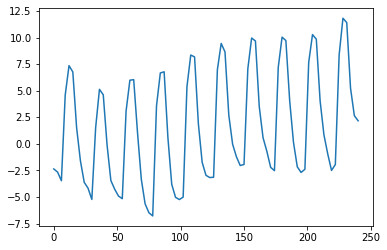

In [ ]:
df_snow['airTemperature.sg'].plot()

In [ ]:
df_snow.to_csv('df_snow.csv', sep = '\t', mode = 'a')